# CT Preprcessing
Notebook for experimenting with different preprocessing steps to build pipelines

In [52]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

In [96]:
img_path = "D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset009_FSFBMask/imagesTr/FSFBMask_001_0000.nii.gz"
mask_path = "D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset009_FSFBMask/labelsTr/FSFBMask_001.nii.gz"

In [14]:
def apply_window(image, wl, ww):
    lower = wl - ww / 2
    upper = wl + ww / 2
    windowed = np.clip(image, lower, upper)
    return windowed

In [32]:
def load_and_standardize(path):
    img = sitk.ReadImage(path)
    img = sitk.DICOMOrient(img, "RAS")
    return img

In [9]:
def plot_volume(volume_path, wl, ww, mask_path=None, z_index=None):
    # Read and orient image
    ct_image = load_and_standardize(volume_path)
    ct_np = sitk.GetArrayFromImage(ct_image)

    if mask_path:
        mask_image = load_and_standardize(mask_path)
        mask_np = sitk.GetArrayFromImage(mask_image)

    def show_slice(idx):
        windowed_slice = apply_window(ct_np[idx], wl, ww)

        plt.imshow(np.fliplr(windowed_slice), cmap="gray", origin="lower")  # fix display flip
        if mask_path:
            plt.imshow(np.fliplr(mask_np[idx]), alpha=0.4, origin="lower")

        plt.title(f"Slice {idx}")
        plt.axis("off")
        plt.show()

    if z_index is not None:
        show_slice(z_index)
    else:
        for i in range(ct_np.shape[0]):
            show_slice(i)

# Identify skull

In [90]:
ct_image = load_and_standardize(img_path)
ct_np = sitk.GetArrayFromImage(ct_image)

In [53]:
skull_mask = sitk.BinaryThreshold(
    ct_image,
    lowerThreshold=200,
    upperThreshold=6000,
    insideValue=1,
    outsideValue=0
)

cc = sitk.ConnectedComponent(skull_mask, True)
stats = sitk.LabelShapeStatisticsImageFilter()
stats.Execute(cc)

largest_label = max(stats.GetLabels(), key=lambda l: stats.GetPhysicalSize(l))

largest_mask = sitk.BinaryThreshold(cc, largest_label, largest_label)
mask_np = sitk.GetArrayFromImage(largest_mask)


In [54]:
z_indices = np.where(mask_np.sum(axis=(1, 2)) > 0)[0]
middle_value = int(np.mean(z_indices))

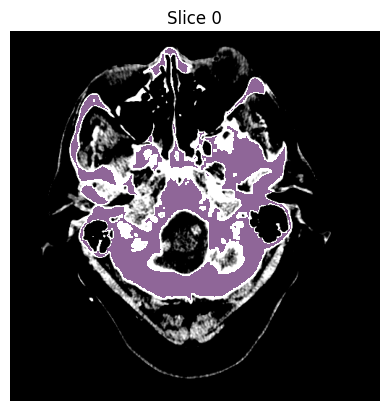

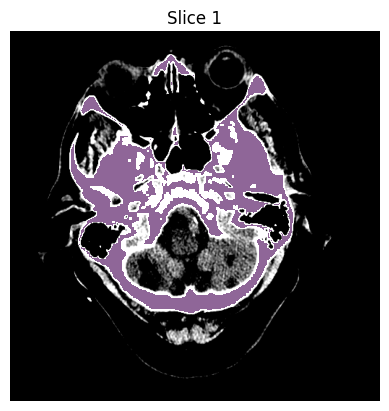

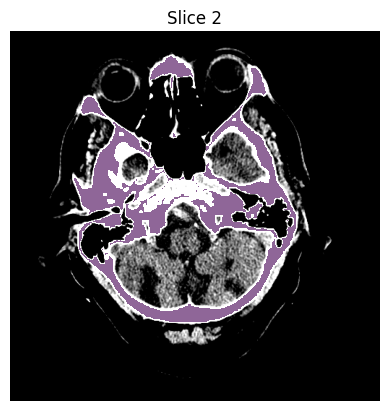

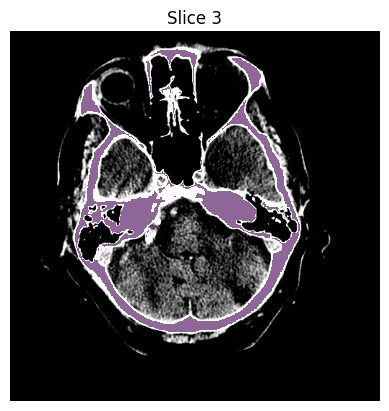

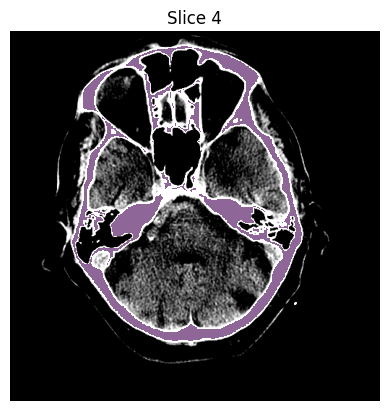

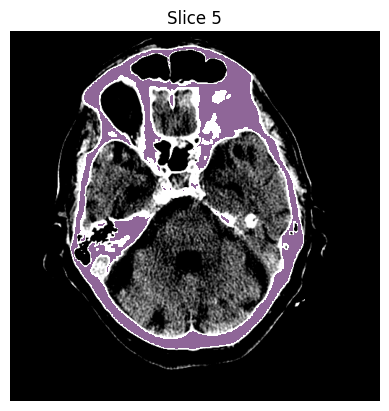

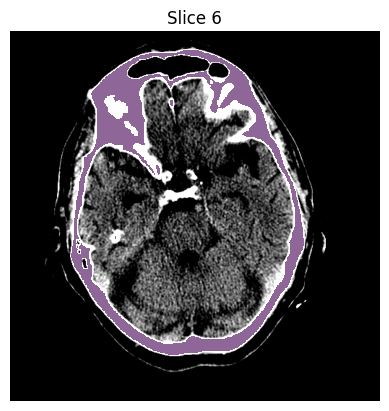

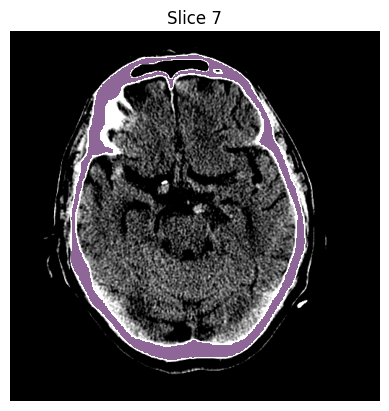

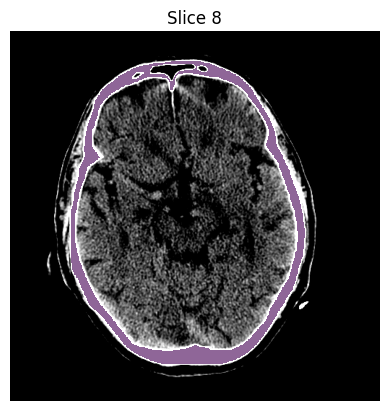

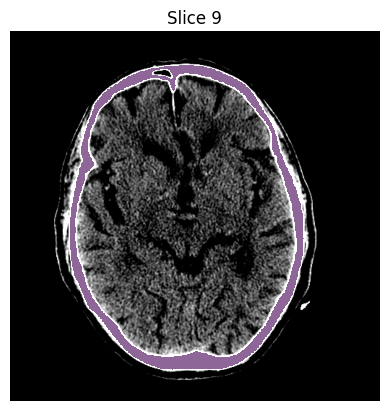

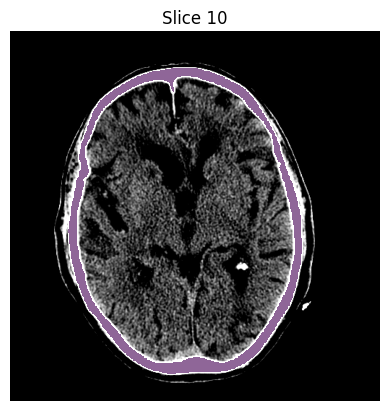

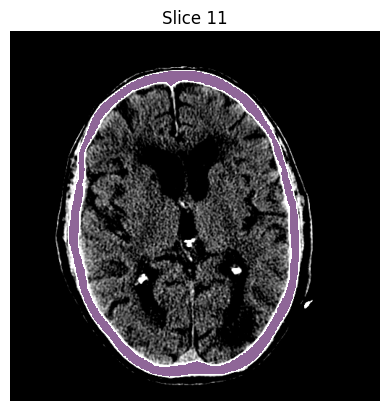

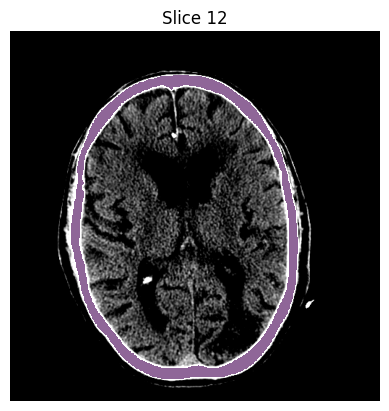

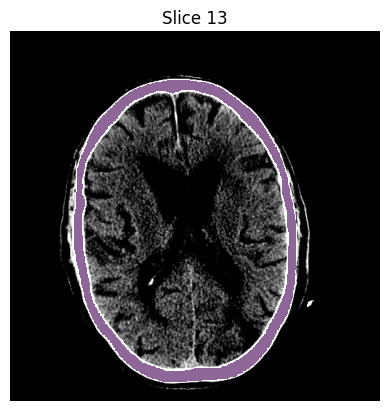

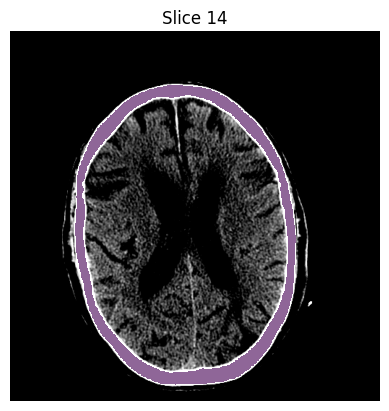

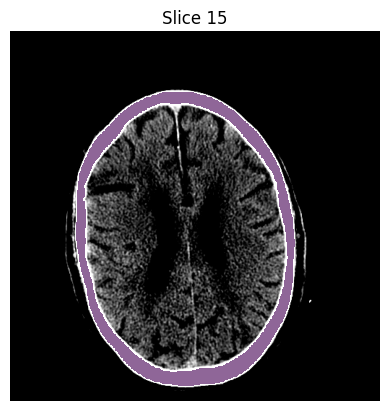

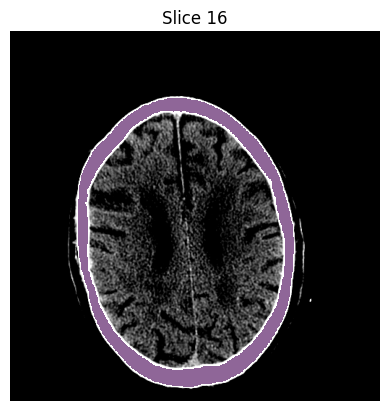

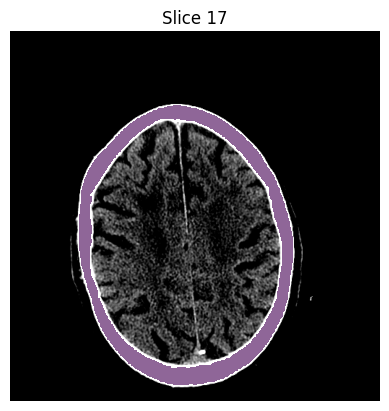

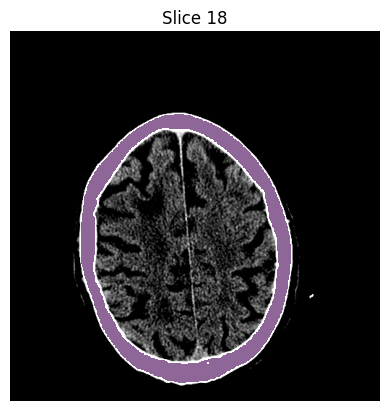

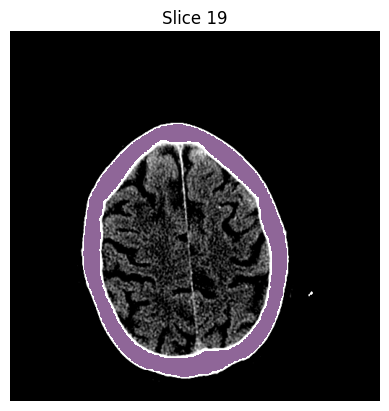

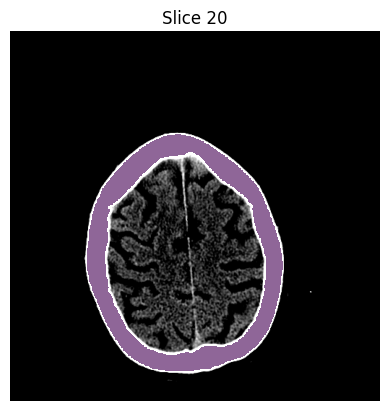

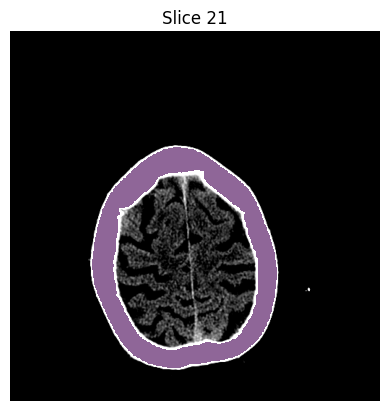

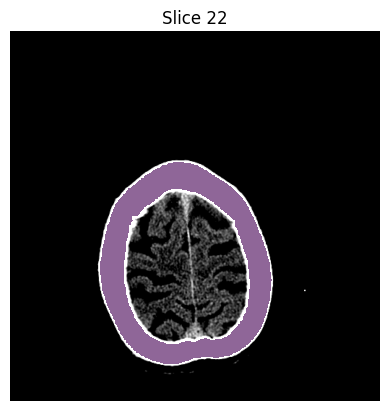

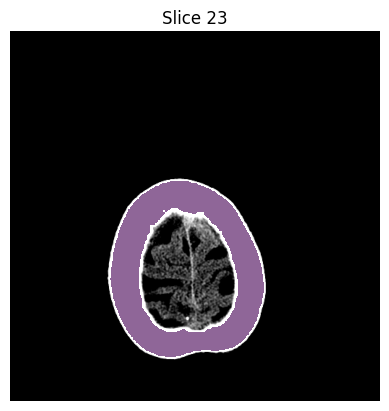

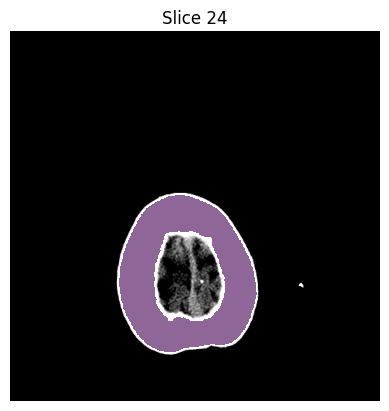

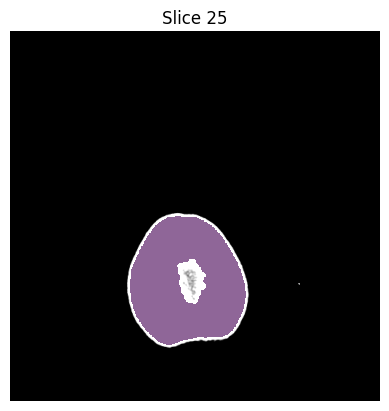

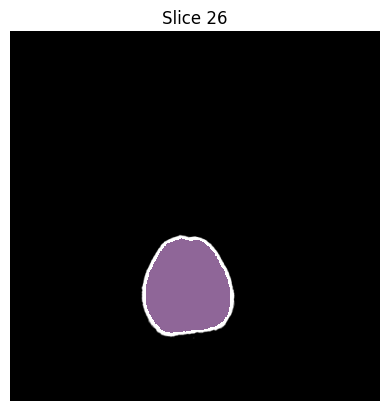

In [102]:
def show_slice(idx):
    windowed_slice = apply_window(ct_np[idx], 40, 40)

    plt.imshow(np.fliplr(windowed_slice), cmap="gray", origin="lower")  # fix display flip
    mask_overlay = np.ma.masked_where(mask_np[idx] == 0, mask_np[idx])
    plt.imshow(np.fliplr(mask_overlay), alpha=0.6, origin="lower")

    plt.title(f"Slice {idx}")
    plt.axis("off")
    plt.show()


for i in range(ct_np.shape[0]):
    show_slice(i)
# show_slice(middle_value)

# Alinear la imagen

In [70]:
slice_mask = mask_np[middle_value]
coords = np.argwhere(slice_mask > 0)  

In [71]:
# Center the data
mean = coords.mean(axis=0)
centered = coords - mean

# Covariance matrix
cov = np.cov(centered, rowvar=False)

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(cov)

# Sort eigenvectors (largest eigenvalue = principal axis)
order = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, order]

principal_axis = eigvecs[:, 0]  # direction of max variance
principal_axis

array([-0.99439634, -0.10571624])

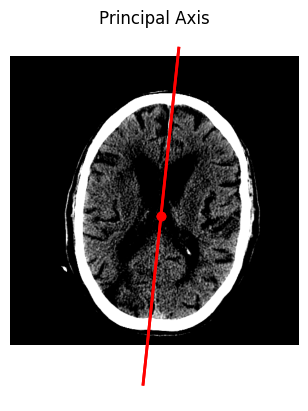

In [74]:
plt.imshow(slice_mask, cmap='gray', origin="lower")

# Center point
cy, cx = mean

# Direction vector
vy, vx = principal_axis

# Scale for visualization (so the line is long enough)
scale = 300

# Line endpoints
x1 = cx - vx * scale
y1 = cy - vy * scale

x2 = cx + vx * scale
y2 = cy + vy * scale

# Plot center
plt.scatter(cx, cy, color='red')

# Plot axis line
plt.plot([x1, x2], [y1, y2], 'r-', linewidth=2)

windowed_slice = apply_window(ct_np[middle_value], 40, 40)

plt.imshow(windowed_slice, cmap="gray", origin="lower") 

# Plot center
plt.scatter(cx, cy, color='red')

# Plot axis line
plt.plot([x1, x2], [y1, y2], 'r-', linewidth=2)

plt.title("Principal Axis")
plt.axis('off')
plt.show()

In [73]:
angle = np.arctan2(principal_axis[0], principal_axis[1])
angle_deg = np.degrees(angle)

# normalize to [-90, 90]
if angle_deg < -90:
    angle_deg += 180
elif angle_deg > 90:
    angle_deg -= 180

rotation = (90 - angle_deg) * -1
rotation

-6.068433621404367

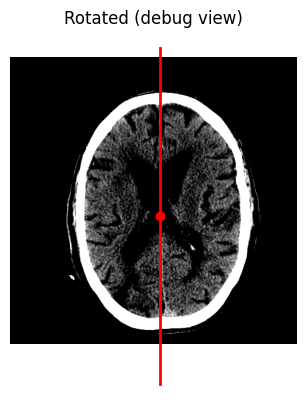

In [61]:
def rotate_point(y, x, cy, cx, angle_deg):
    angle = np.radians(angle_deg)
    
    # shift to origin
    y0 = y - cy
    x0 = x - cx
    
    # rotate
    y_rot =  y0 * np.cos(angle) - x0 * np.sin(angle)
    x_rot =  y0 * np.sin(angle) + x0 * np.cos(angle)
    
    # shift back
    return y_rot + cy, x_rot + cx

# original endpoints
y1_rot, x1_rot = rotate_point(y1, x1, cy, cx, rotation)
y2_rot, x2_rot = rotate_point(y2, x2, cy, cx, rotation)

rotated_slice = rotate(
    ct_np[middle_value],
    rotation,        # degrees
    reshape=False,   # keep same size
    order=1          # linear interpolation
)

# original endpoints
y1_rot, x1_rot = rotate_point(y1, x1, cy, cx, rotation)
y2_rot, x2_rot = rotate_point(y2, x2, cy, cx, rotation)

windowed_slice = apply_window(rotated_slice, 40, 40)
plt.imshow(windowed_slice, cmap='gray', origin="lower")

# plot rotated center (same point)
plt.scatter(cx, cy, color='red')

# plot rotated axis
plt.plot([x1_rot, x2_rot], [y1_rot, y2_rot], 'r-', linewidth=2)

plt.title("Rotated (debug view)")
plt.axis('off')
plt.show()

In [97]:
# Get the center of mass of the image
stats = sitk.LabelShapeStatisticsImageFilter()
stats.Execute(largest_mask)

label = 1
center_physical = stats.GetCentroid(label)
print(center_physical)

# Get the vertical axis to rotate
direction = ct_image.GetDirection()
direction_matrix = np.array(direction).reshape(3,3)
vertical_ax = direction_matrix[:,2]
print(vertical_ax)

# Rotate colume using Simple ITK
transform = sitk.VersorRigid3DTransform()
transform.SetCenter(center_physical)
angle_rad = np.deg2rad(rotation)
transform.SetRotation(vertical_ax.tolist(), angle_rad)


resampled = sitk.Resample(
    ct_image,   # input image
    ct_image,   # Image to take into accout for output size, spacing, origin, direction, etc.
    transform,  # Transformation to apply
    sitk.sitkBSpline,    # Iterpolator, other options are sitk.sitklinear, sitk.sitkBSpline and sitk.sitkNearesNeighbor
    -1024,        # Value to use when coordinates fall outside the image
    ct_image.GetPixelID()   # Keeps the same datatype for value representation
)

mask_image = load_and_standardize(mask_path)

resampled_mask = sitk.Resample(
    mask_image,   # input image
    ct_image,   # Image to take into accout for output size, spacing, origin, direction, etc.
    transform,  # Transformation to apply
    sitk.sitkNearestNeighbor,    # Iterpolator, other options are sitk.sitklinear, sitk.sitkBSpline and sitk.sitkNearesNeighbor
    0,        # Value to use when coordinates fall outside the image
    mask_image.GetPixelID()   # Keeps the same datatype for value representation
)

(-6.588789399008363, 13.211840888699754, -118.03782250631735)
[0.         0.17694467 0.9842208 ]


In [99]:
np.unique(resampled_mask_arr)

array([0, 1], dtype=uint16)

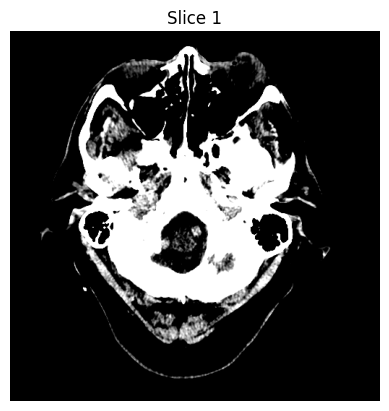

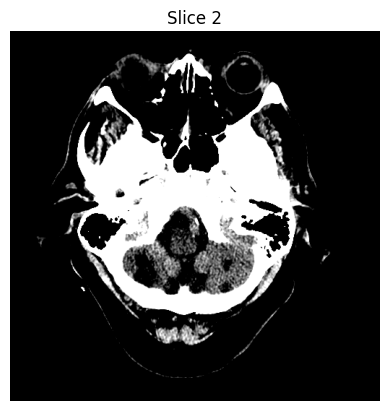

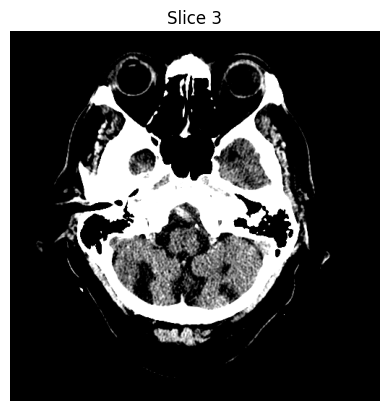

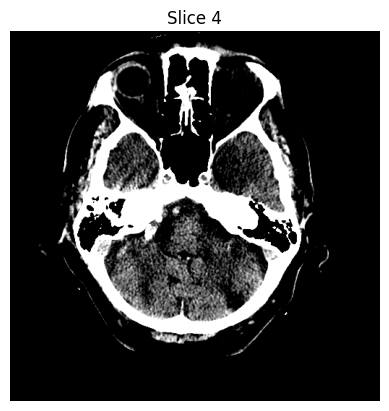

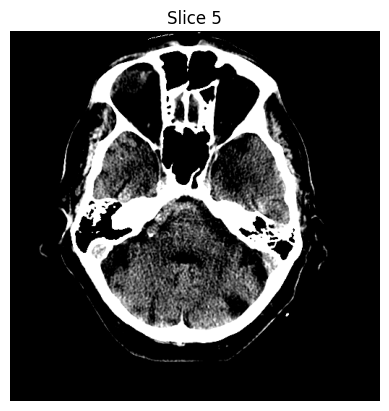

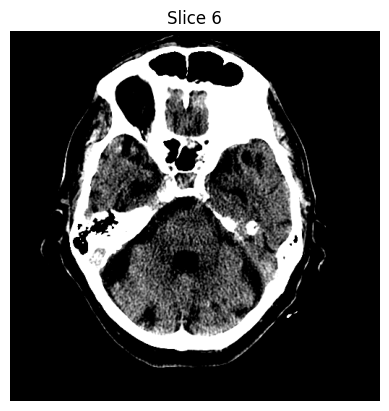

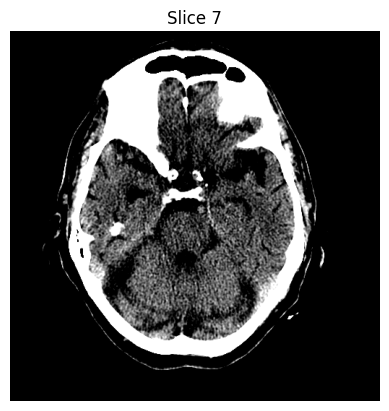

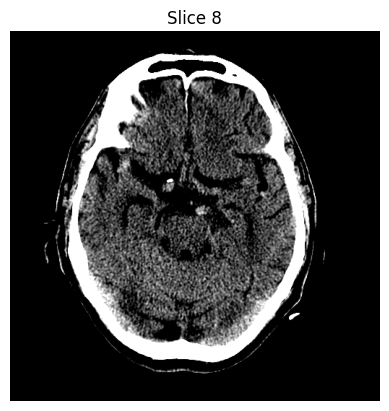

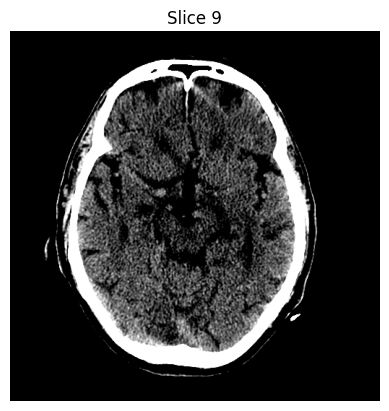

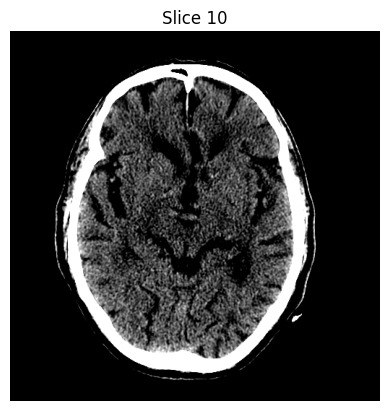

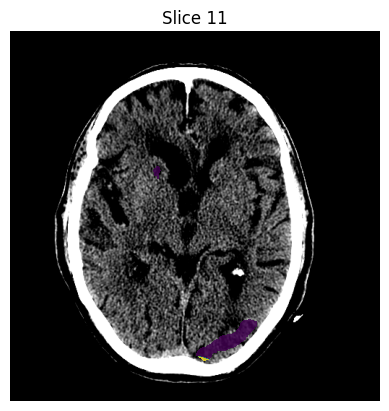

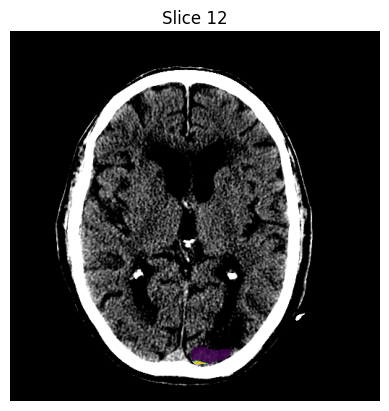

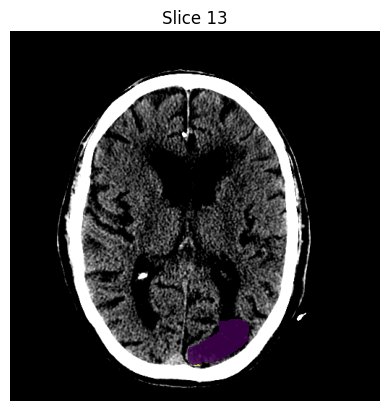

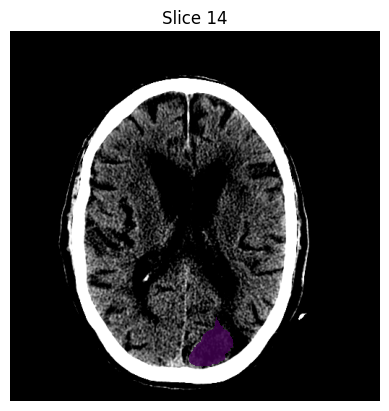

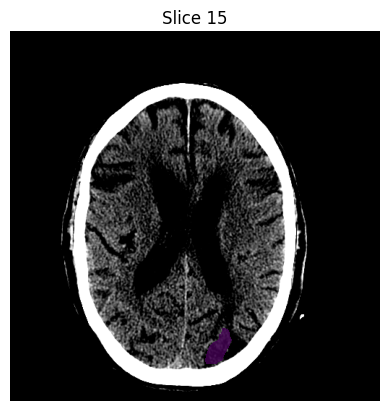

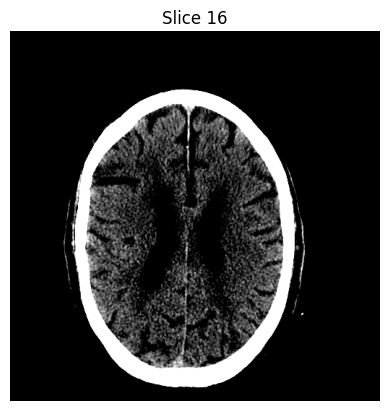

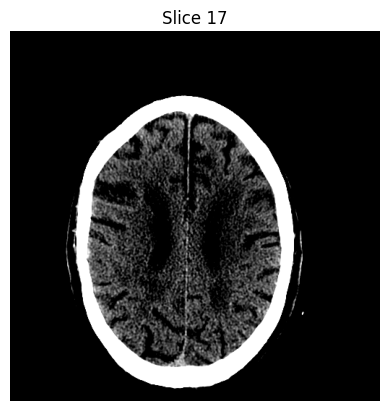

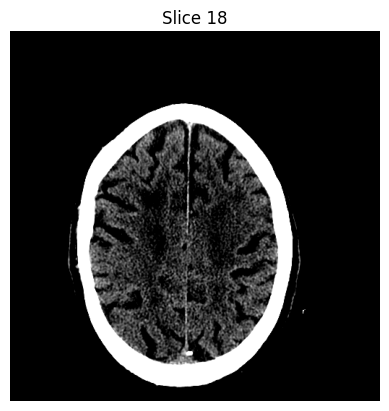

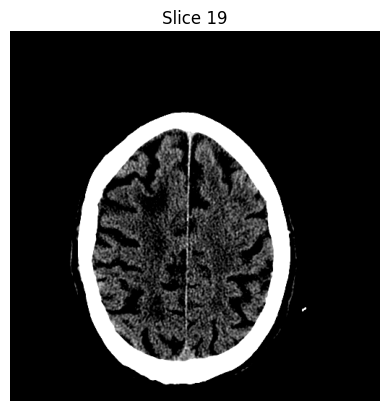

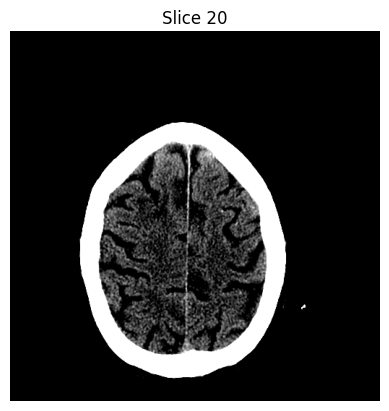

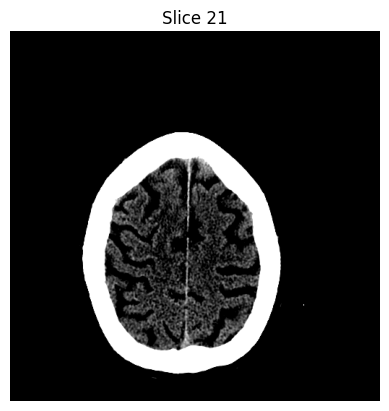

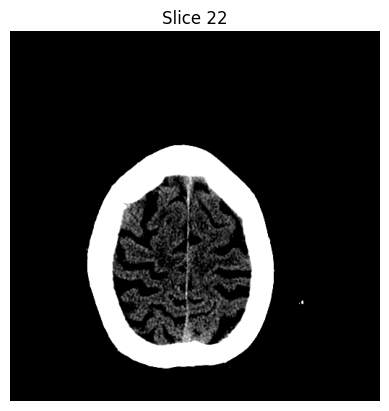

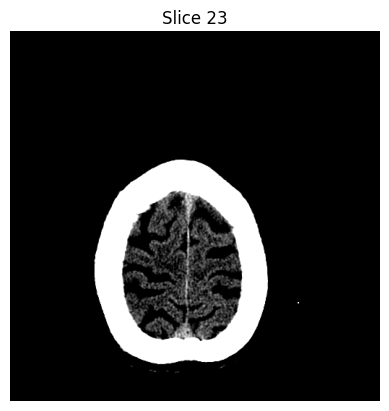

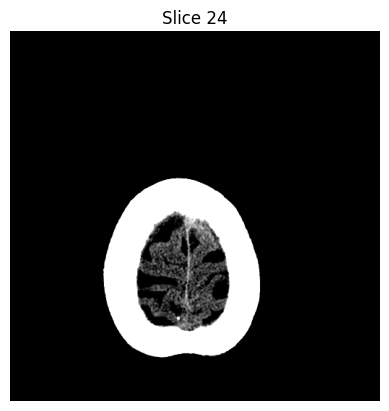

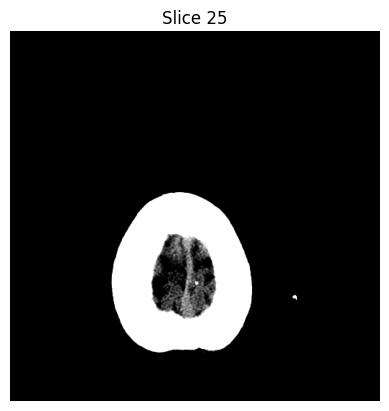

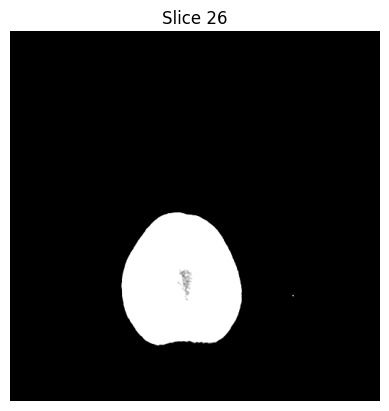

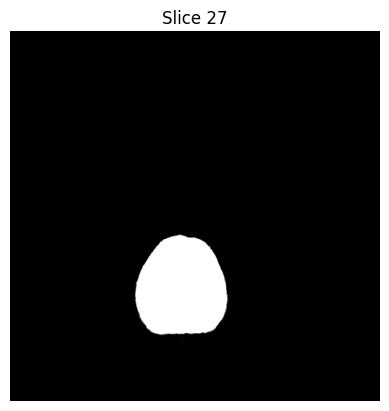

In [101]:
resampled_arr = sitk.GetArrayFromImage(resampled)  # (z, y, x)
resampled_mask_arr = sitk.GetArrayFromImage(resampled_mask)  # (z, y, x)
def show_slice(idx):
    windowed_slice = apply_window(resampled_arr[idx], 40, 40)

    plt.imshow(np.fliplr(windowed_slice), cmap="gray", origin="lower")  # fix display flip
    mask_overlay = np.ma.masked_where(resampled_mask_arr[idx] == 0, mask_np[idx])
    plt.imshow(np.fliplr(mask_overlay), alpha=0.8, origin="lower")

    plt.title(f"Slice {idx+1}")
    plt.axis("off")
    plt.show()


for i in range(resampled_arr.shape[0]):
    show_slice(i)